# 📋TP Python - Partie 2
---
## 🗓 Programme
- 25/03/2025 - Prise en main de Python
- **02/04/2025 - Cas pratique d'analyse de données**
- 03/04/2025 - Révisions et Evaluation



## 🎯Objectifs du jour :
- Charger des données
- Exploiter les données
- Générer des graphiques


Manipulation des données avec Pandas :
https://pandas.pydata.org/docs/user_guide/index.html

Représentation des données avec Plotly :
https://plotly.com/python/



In [1]:
#Pré-requis technique d'installation de package pour la suite du TP.
import sys
!{sys.executable} -m pip install numpy pandas plotly

## 🟢 La librairie Pandas (≈ 2h00 min)

### Découverte de Pandas (10 min)
### Chargement de la librairie

La documentation de référence est disponible ici :
https://pandas.pydata.org/docs/user_guide/index.html


In [2]:
import pandas as pd


### Création d'une série


In [3]:
#Une serie est un tableau à une seule dimension (liste)
s = pd.Series([1, 3, 4, 5, 6, 8])
s

0    1
1    3
2    4
3    5
4    6
5    8
dtype: int64

In [4]:

#affichage du minimum
print(s.min())
#affichage du maximum
print(s.min())
#affichage de la moyenne
print(s.mean())
#affichage de la taille de la série
print(s.count())
#et plein d'auters fonctions disponibles sur la documentation des séries ici :
# https://pandas.pydata.org/docs/reference/series.html#computations-descriptive-stats


1
1
4.5
6


---
#### 💪 Exercice 1.1
A partir de cette série qui liste plusieurs volumes de productions pour la journée d'hier:
```
volumes_production = pd.Series([254, 321, 214, 312, 221, 197, 368])
```
générez la phrase suivante :
*EntoNova a lancé hier x chaînes de fabrication pour une production totale de y produits*

### Création d'un Tableau (DataFrame)


In [5]:
#Un DataFrame est un tableau à deux dimensions
df = pd.DataFrame(
    {
        "Animal": ["Falcon", "Falcon", "Parrot", "Parrot", "Humming-bird", "Humming-bird"],
        "Max Speed (km/h)": [380.0, 370.0, 24.0, 26.0, 96.0, 101.0],
    }
)
df

,Animal,Max Speed (km/h)
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0
4,Humming-bird,96.0
5,Humming-bird,101.0


D'autres méthodes et attributs seront nécessaires pour la réalisation des exercices notamment :
- nunique()
- unique()
- sort_values()
- columns
- shape

Plus d'informations ici :
https://pandas.pydata.org/docs/reference/frame.html


In [6]:
#la fonction mean() Calcule une moyenne ici sur la colonne Max Speed
df["Max Speed (km/h)"].mean()


np.float64(166.16666666666666)

In [7]:
#La fonction groupby() permet de regrouper le résultat en regroupant une colonne
#Ici mean s'applique à toutes les autres colonnes que Animal soit dans ce cas uniquement Max Speed
df.groupby(["Animal"]).mean()

,Max Speed (km/h)
Animal,
Falcon,375.0
Humming-bird,98.5
Parrot,25.0


In [8]:
#On peut aussi préciser la colonne sur laquelle appliquer la fonction - utile sur les Dataframe à plusieurs colonnes
df.groupby(["Animal"])["Max Speed (km/h)"].mean()

Animal
Falcon          375.0
Humming-bird     98.5
Parrot           25.0
Name: Max Speed (km/h), dtype: float64

In [9]:
#Notez l'absence de nom de colonne sur l'exemple ci-dessous. La fonction reset_index() permet de récupérer les noms de colonne pour pouvoir les utiliser ultérieurement
df.groupby(["Animal"])["Max Speed (km/h)"].mean().reset_index()

,Animal,Max Speed (km/h)
0,Falcon,375.0
1,Humming-bird,98.5
2,Parrot,25.0


In [10]:
#la fonction mean() Calcule la valeur max()
df.groupby(["Animal"]).max()

,Max Speed (km/h)
Animal,
Falcon,380.0
Humming-bird,101.0
Parrot,26.0


In [11]:
# la fonction head() affiche les 5 premières lignes
# Utile pour avoir un aperçu sur les gros fichiers
df.head()

,Animal,Max Speed (km/h)
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0
4,Humming-bird,96.0


In [12]:
#Ajout d'une colonne Max Speed (m/s)
df["Max Speed (m/s)"] = df["Max Speed (km/h)"] *(1000/3600)
df


,Animal,Max Speed (km/h),Max Speed (m/s)
0,Falcon,380.0,105.555556
1,Falcon,370.0,102.777778
2,Parrot,24.0,6.666667
3,Parrot,26.0,7.222222
4,Humming-bird,96.0,26.666667
5,Humming-bird,101.0,28.055556


In [13]:
#Affichage des vitesses > 100 km/h
df[df["Max Speed (km/h)"] > 100]

,Animal,Max Speed (km/h),Max Speed (m/s)
0,Falcon,380.0,105.555556
1,Falcon,370.0,102.777778
5,Humming-bird,101.0,28.055556


---
## Exercice 2

A partir de ce DataFrame :

In [14]:
ventes = pd.DataFrame(
    {
        "client" : ["VeggieWorld", "GreenFood", "NutriPlus", "EcoStore", "VeggieWorld", "BioPlanet"],
        "pays" : ["France", "Allemagne", "Canada", "Japon", "France", "Belgique"],
        "produit" : ["Barre grillons", "Barre grillons", "Poudre insectes", "Snack protéiné", "Snack protéiné", "Barre grillons"],
        "quantite" : [120, 340, 80, 210, 95, 180],
        "prix_unitaire" : [3, 3, 12, 4, 4, 3]
    }
)
ventes.head()

,client,pays,produit,quantite,prix_unitaire
0,VeggieWorld,France,Barre grillons,120,3
1,GreenFood,Allemagne,Barre grillons,340,3
2,NutriPlus,Canada,Poudre insectes,80,12
3,EcoStore,Japon,Snack protéiné,210,4
4,VeggieWorld,France,Snack protéiné,95,4


---
### Explorer le DataFrame (20 min)
#### 💪 Exercice 2.1

Afficher le nombre de lignes et de colonnes

```x lignes et y colonnes```

---
#### 💪 Exercice 2.2

Afficher les entêtes de colonnes


---
#### 💪 Exercice 2.3

Calculer le nombre de produits différents
Calculer le nombre de clients différents


---
### Calculs et transformation des données (20 min)
#### 💪 Exercice 2.4

Ajouter une colonne ```prix``` calculée à partir de ```prix_unitaire``` et de ```quantite```
Afficher ensuite le nouveau tableau


---
#### 💪 Exercice 2.5
Afficher le total de toutes les commandes de chaque client

---
#### 💪 Exercice 2.6
Afficher le chiffre d'affaire pour toutes ces commandes

---
#### 💪 Exercice 2.7
Pour chaque type de produits, afficher le nombre de produits vendus 

---
### Analyse commerciale (20 min)
#### 💪 Exercice 2.8
Afficher uniquement les commandes supérieures à une quantité de 200

---
#### 💪 Exercice 2.8
Afficher le chiffre d'affaire par produit

---
#### 💪 Exercice 2.9
Afficher le chiffre d'affaire par pays

---
#### 💪 Exercice 2.10
Ordonner le tableau de ventes par quantité décroissante.

---
## Exercice 3

### Travaux sur gros volumes (50 min)

A partir de ce DataFrame chargé à partir d'un fichier au format CSV :

In [15]:
#lecture d'un fichier CSV
df = pd.read_csv('../data/entonova_ventes_100k.csv',parse_dates=True)
#conversion en fomat date pour exploitation
df['date'] = pd.to_datetime(df['date'])


---
### 💪 Exercice 3.1

Afficher les 5 premières lignes du fichier :

---
### 💪 Exercice 3.2

Combien y'a-t-il de lignes dans ce fichier ?

---
### 💪 Exercice 3.3
Créer une nouvelle colonne ```prix``` pour afficher le prix de chaque commande


---
### 💪 Exercice 3.4
Lister les différents produits vendus

---
### 💪 Exercice 3.5
Lister le nombre de clients

---
### 💪 Exercice 3.6
Quel est le chiffre d'affaire par client ?

---
### 💪 Exercice 3.7
Donnez la moyenne du prix unitaire / produit

---
### 💪 Exercice 3.8
En vous servant de l'aide ici :
#https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.year.html
#https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.month.html
Créez 2 nouvelles colonnes ```mois``` et ```année```


---
### 💪 Exercice 3.9
Quel est le chiffre d'affaire annuel ?

---
### 💪 Exercice 3.10
Quel est le chiffre d'affaire /produit /an ?
 
un group_by avec plusieurs critères se fait avec cette syntaxe :
```groupby(["critère principal","critère secondaire"])```


---
### 💪 Exercice 3.11
Quel est le chiffre d'affaire /client /mois en 2026 ?


---
### 💪 Exercice 3.12
Quel est le chiffre d'affaire /client /mois en 2026 ?

## 🟢 La librairie Plotly (≈ 1h30 min)
### Chargement de la librairie

La documentation de référence est disponible ici :
https://plotly.com/python/

In [16]:
from plotly.offline import init_notebook_mode, iplot
from plotly.graph_objs import *
import plotly.express as px

init_notebook_mode(connected=True)         # permet d'afficher le résultat dans le notebook

### Utilisation de la librairie
Pour la suite de l'exerice, insprirez-vous de cet exemple :

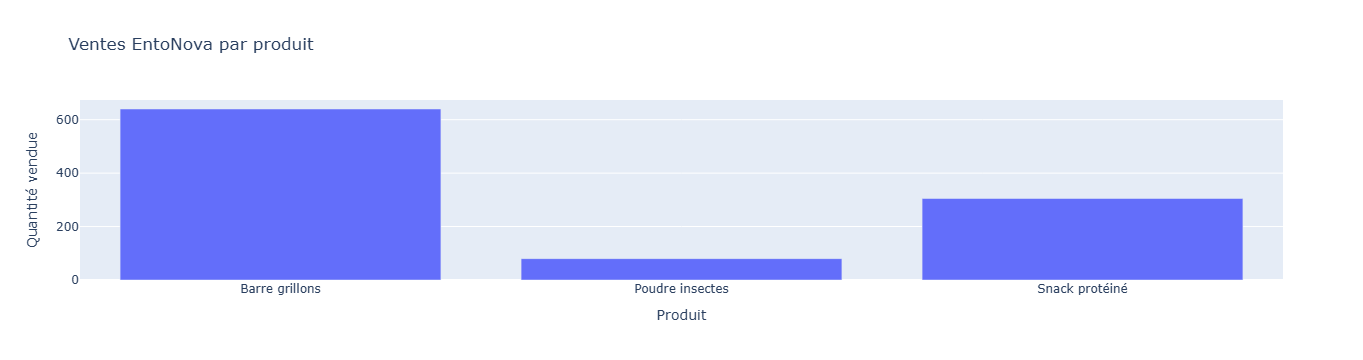

In [17]:
data = {
    "produit": [
        "Barre grillons",
        "Poudre insectes",
        "Snack protéiné",
        "Barre grillons",
        "Snack protéiné"
    ],
    "quantite": [
        120,
        80,
        210,
        340,
        95
    ]
}

ventes_produit = ventes.groupby("produit")["quantite"].sum().reset_index()

fig = px.bar(
    ventes_produit,
    x="produit",
    y="quantite",
    title="Ventes EntoNova par produit",
    labels={
        "produit": "Produit",
        "quantite": "Quantité vendue"
    }
)

fig.show()

---
## Exercice 4
### 💪 Exercice 4.1
Afficher le chiffre d'affaire par client par mois de 2026 en utilisant cette représentation avec une couleur par client :
https://plotly.com/python/line-charts/#line-plots-with-column-encoding-color 

N'oubliez pas de toujours mettre un titre représentatif du graphique

### 💪 Exercice 4.2
Afficher le chiffre d'affaire par type de produit et par an en utilisant ces graphiques :
https://plotly.com/python/bar-charts/#bar-charts-with-text


### 💪 Exercice 4.3
Générez un graphique montrant les écarts de prix unitaires des barres protéinées en 2026 en affichant les points de chaque vente
https://plotly.com/python/box-plots/

### 💪 Exercice 4.3
Pour chaque type de produit, Générer un nouveau graphique montrant la moyenne des prix unitaires annuels
https://plotly.com/python/line-charts/#line-plots-with-plotlyexpress

A partir de cet exemple vous pourrez réaliser l'exercice 4.4

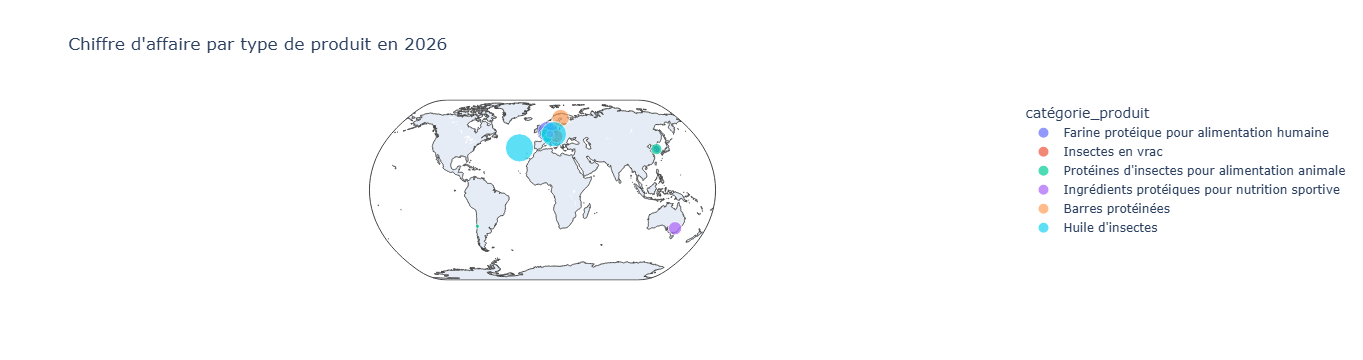

In [19]:
df2 = pd.read_csv('../data/entonova_geo_ventes.csv')

group = df2.groupby(["année","nom_client","catégorie_produit", "latitude", "longitude"])["prix"].sum().reset_index()

def geo_quantity(year) :
    fig = px.scatter_geo(group[group["année"] == year] , lat="latitude", lon="longitude", color="catégorie_produit",
                     hover_name="nom_client", size="prix",
                     projection="natural earth", title="Chiffre d'affaire par type de produit en " + str(year))
    fig.show()
    
geo_quantity(2026)

### 💪 Exercice 4.4
A partir de l'exemple ci-dessus, animer la carte pour afficher l'évolution géographique annuelle des volumes de ventes par produit https://plotly.com/python/bubble-maps/
https://plotly.com/python/bubble-maps/